In [7]:
%pip install "numpy>=2.0,<2.3" --force-reinstall

  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


In [1]:
# python
import sys
import copy
import gc
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local

sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import pandas as pd
import mplhep as hep
import yaml
from sidm.tools.utilities import plot_data_mc
from pathlib import Path

In [2]:
# Load signal sample names, keeping only mass points from 200 GeV.
signal_yaml_paths = [
    "../../configs/ntuples/signal_2mu2e_v10.yaml",
    "../../configs/ntuples/signal_4mu_v10.yaml",
]
signal_lists = []
for yaml_file_path in signal_yaml_paths:
    with open(yaml_file_path, "r") as file:
        signal_cfg = yaml.safe_load(file)
    signal_lists.append(list(signal_cfg["llpNanoAOD_v2"]["samples"]))

signals_2mu2e_all, signals_4mu_all = signal_lists
signals_all = [
    sample
    for sample in signals_2mu2e_all + signals_4mu_all
    if int(sample.split("_")[1].removesuffix("GeV")) >= 200
]
print(f"Selected {len(signals_all)} signal points with mH >= 200 GeV")

try:
    out
    print("The out dictionary already exists; reusing and trimming cached samples")
except NameError:
    print("WARNING! No processor output stored in memory; loading signal coffea files")
    out = {}

required_hists = {"mulj_egmlj_iso", "mulj_mulj_iso"}
input_dir = Path("test_ABCD_signal_full_merge_v1")

for sample in signals_all:
    output = loaded_out = payload = kept_hists = None
    try:
        if sample in out:
            payload = out[sample]
            print(f"{sample} already found in memory; trimming payload")
        else:
            input_file = input_dir / f"{sample}.coffea"
            print(f"Loading {input_file}")
            output = coffea.util.load(input_file)
            loaded_out = output.get("out", output)
            payload = loaded_out[sample]

        kept_hists = {
            name: payload["hists"][name]
            for name in required_hists
            if name in payload.get("hists", {})
        }
        if not kept_hists:
            raise KeyError("none of the required ABCD histograms were found")
        out[sample] = {"hists": kept_hists}
        print(f"Successfully kept {sorted(kept_hists)}")
    except FileNotFoundError:
        print(f"**** File not found for {sample}")
    except Exception as error:
        print(f"**** Failed to load {sample}: {error}")
        out.pop(sample, None)
    finally:
        output = loaded_out = payload = kept_hists = None
        gc.collect()


Selected 120 signal points with mH >= 200 GeV
WARNING! No processor output stored in memory; loading signal coffea files
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_0p01mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_0p1mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_1p0mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_5p0mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_10p0mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_1p2GeV_0p048mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_1p2GeV_0p48mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mul

In [3]:
samples_bkg = [
    "TTJets",
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120", 
    "QCD_Pt120To170",
    "QCD_Pt170To300", 
    "QCD_Pt300To470",
    "QCD_Pt470To600", 
    "QCD_Pt600To800", 
    "QCD_Pt800To1000",
    "QCD_Pt1000", 
    "DYJetsToLL_M10to50",
    "DYJetsToLL_M50", 
    "WW",
    "WZ",
    "ZZ",
]

samples_data= [ 
    "DoubleMuon_2018A_0",
    "DoubleMuon_2018A_1",
    "DoubleMuon_2018A_2",

    "DoubleMuon_2018B_0",
    "DoubleMuon_2018B_1",
    "DoubleMuon_2018B_2",
    "DoubleMuon_2018B_3",
    "DoubleMuon_2018B_4",
    "DoubleMuon_2018B_5",
    "DoubleMuon_2018B_6",
    "DoubleMuon_2018B_7",
    "DoubleMuon_2018B_8",
    "DoubleMuon_2018B_9",
    "DoubleMuon_2018B_10",
    "DoubleMuon_2018B_11",
    "DoubleMuon_2018B_12",
    "DoubleMuon_2018B_13",
    
    "DoubleMuon_2018C",

    "DoubleMuon_2018D_0",
    "DoubleMuon_2018D_1",
    "DoubleMuon_2018D_2",
    "DoubleMuon_2018D_3",
    "DoubleMuon_2018D_4",
    "DoubleMuon_2018D_5",
    "DoubleMuon_2018D_6",
    "DoubleMuon_2018D_7",
    "DoubleMuon_2018D_8",
    "DoubleMuon_2018D_9",
    "DoubleMuon_2018D_10",
    "DoubleMuon_2018D_11",
    "DoubleMuon_2018D_12",
    "DoubleMuon_2018D_13",
    "DoubleMuon_2018D_14",
    "DoubleMuon_2018D_15",
    "DoubleMuon_2018D_16",
    "DoubleMuon_2018D_17",
    "DoubleMuon_2018D_18",
    "DoubleMuon_2018D_19",
    "DoubleMuon_2018D_20",
    "DoubleMuon_2018D_21",
    "DoubleMuon_2018D_22",
    "DoubleMuon_2018D_23",
    "DoubleMuon_2018D_24",
    "DoubleMuon_2018D_25",
    "DoubleMuon_2018D_26",
    "DoubleMuon_2018D_27",
    "DoubleMuon_2018D_28",
    "DoubleMuon_2018D_29",
    "DoubleMuon_2018D_30",
    "DoubleMuon_2018D_31",
    "DoubleMuon_2018D_32",
    "DoubleMuon_2018D_33",
    "DoubleMuon_2018D_34",
    "DoubleMuon_2018D_35",
    "DoubleMuon_2018D_36",
    "DoubleMuon_2018D_37",
    "DoubleMuon_2018D_38",
    "DoubleMuon_2018D_39",
    "DoubleMuon_2018D_40",
    "DoubleMuon_2018D_41",
    "DoubleMuon_2018D_42",
    "DoubleMuon_2018D_43",
    "DoubleMuon_2018D_44",
    "DoubleMuon_2018D_45",
    "DoubleMuon_2018D_46",
    "DoubleMuon_2018D_47",
    "DoubleMuon_2018D_48",
    "DoubleMuon_2018D_49",
]

In [4]:
# Keep only the two isolation planes used by the ABCD study.
required_hists = {"mulj_egmlj_iso", "mulj_mulj_iso"}

#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples_bkg:
    output = loaded_out = payload = kept_hists = None
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = sample + ".coffea"
        try:
            output = coffea.util.load("test_ABCD_bkg_full_merge_v1/"+filename)
            loaded_out = output.get("out", output)
            payload = loaded_out[sample]
            kept_hists = {
                name: payload["hists"][name]
                for name in required_hists
                if name in payload.get("hists", {})
            }
            out[sample] = {"hists": kept_hists}
            print(f"Successfully kept {sorted(kept_hists)}")
        except Exception as error:
            print(f"**** Failed to load {filename}: {error}")
        finally:
            output = loaded_out = payload = kept_hists = None
            gc.collect()

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample TTJets
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt15To20
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt20To30
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt30To50
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt50To80
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt80To120
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt120To170
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt170To300
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt300To470
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt470To600
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loadi

In [5]:
# Keep only the two isolation planes used by the ABCD study.
required_hists = {"mulj_egmlj_iso", "mulj_mulj_iso"}

#First check if there is already an out dictionary
try:
    out_data
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out_data = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for data in samples_data:
    output = loaded_out = payload = kept_hists = None
    if data in out_data:
        print(f"{data} already found in memory; not loading file")
    else:
        print(f"Loading file for data {data}")
        filename = data + ".coffea"
        try:
            output = coffea.util.load("test_ABCD_data_full_merge_v1/"+filename)
            loaded_out = output.get("out", output)
            payload = loaded_out[data]
            kept_hists = {
                name: payload["hists"][name]
                for name in required_hists
                if name in payload.get("hists", {})
            }
            out_data[data] = {"hists": kept_hists}
            print(f"Successfully kept {sorted(kept_hists)}")
        except Exception as error:
            print(f"**** Failed to load {filename}: {error}")
        finally:
            output = loaded_out = payload = kept_hists = None
            gc.collect()

WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead
Loading file for data DoubleMuon_2018A_0
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018A_1
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018A_2
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_0
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_1
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_2
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_3
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_4
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_5
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data Do

In [6]:
# Assemble the lightweight payloads and define every setting used below.
BLIND_SR_DATA_A = True
BACKGROUND_ORDER = ["QCD", "DY", "TTJets", "Diboson"]
COLORS = {
    "QCD": "#4c78a8",
    "DY": "#f58518",
    "TTJets": "#54a24b",
    "Diboson": "#e45756",
}
SCAN_VALUES = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])

CHANNEL_CONFIGS = {
    "2mu2e": {
        "hist": "mulj_egmlj_iso",
        "SR": "test_SR_2mu2e",
        "VR": "test_VR_2mu2e",
        "cuts": (0.25, 0.10),
        "x_label": r"$I_{\mu LJ}$",
        "y_label": r"$I_{e/\gamma LJ}$",
    },
    "4mu": {
        "hist": "mulj_mulj_iso",
        "SR": "test_SR_4mu",
        "VR": "test_VR_4mu",
        "cuts": (0.25, 0.25),
        "x_label": r"leading $I_{\mu LJ}$",
        "y_label": r"subleading $I_{\mu LJ}$",
    },
}


def classify_sample(sample):
    if sample.startswith("DoubleMuon"):
        return "Data"
    if sample.startswith("QCD_"):
        return "QCD"
    if sample.startswith("DYJetsTo"):
        return "DY"
    if sample.startswith("TTJets"):
        return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}:
        return "Diboson"
    if sample.startswith(("2Mu2E_", "4Mu_")):
        return "Signal"
    return "Other"


outputs = {**out, **out_data}
sample_groups = {}
for sample in outputs:
    sample_groups.setdefault(classify_sample(sample), []).append(sample)

sample_groups["BKG total"] = sum(
    (sample_groups.get(group, []) for group in BACKGROUND_ORDER),
    [],
)
sample_groups["Signal"] = [
    sample for sample in signals_all if sample in outputs
]

print({group: len(samples) for group, samples in sample_groups.items()})
print(f"Lightweight samples ready: {len(outputs)}")


{'Signal': 120, 'TTJets': 1, 'QCD': 12, 'DY': 2, 'Diboson': 3, 'Data': 68, 'BKG total': 18}
Lightweight samples ready: 206


In [7]:
def sample_hist(sample, topology, region_type):
    cfg = CHANNEL_CONFIGS[topology]
    hist = outputs[sample]["hists"][cfg["hist"]]
    if "channel" in hist.axes.name:
        hist = hist[{"channel": cfg[region_type]}]
    return hist


def group_hist(group, topology, region_type):
    hists = []
    members = [group] if group in outputs else sample_groups.get(group, [])
    for sample in members:
        try:
            hists.append(sample_hist(sample, topology, region_type))
        except (KeyError, ValueError, IndexError):
            pass
    if not hists:
        return None
    total = hists[0].copy()
    for hist in hists[1:]:
        total = total + hist
    return total


def values_variances(h2d):
    values = np.asarray(h2d.values(flow=False), dtype=float)
    variances = h2d.variances(flow=False)
    if variances is None:
        variances = np.clip(values, 0, None)
    return values, np.asarray(variances, dtype=float)


def abcd_masks(h2d, xcut, ycut):
    x = np.asarray(h2d.axes[0].centers)[:, None]
    y = np.asarray(h2d.axes[1].centers)[None, :]
    return {"A": (x < xcut) & (y < ycut),
            "B": (x >= xcut) & (y < ycut),
            "C": (x < xcut) & (y >= ycut),
            "D": (x >= xcut) & (y >= ycut)}


def abcd_yields(h2d, cuts, blind_a=False):
    values, variances = values_variances(h2d)
    result = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        result[region] = (np.nan, np.nan) if region == "A" and blind_a else (
            values[mask].sum(), np.sqrt(np.clip(variances[mask].sum(), 0, None)))
    return result


def prediction(yields):
    b, eb = yields["B"]; c, ec = yields["C"]; d, ed = yields["D"]
    if d <= 0 or not np.all(np.isfinite([b, eb, c, ec, d, ed])):
        return np.nan, np.nan
    pred = b*c/d
    terms = [(eb/b)**2 if b else 0, (ec/c)**2 if c else 0, (ed/d)**2]
    return pred, abs(pred)*np.sqrt(sum(terms))


def closure(h2d, cuts, blind_a=False):
    y = abcd_yields(h2d, cuts, blind_a)
    pred, epred = prediction(y)
    obs, eobs = y["A"]
    kappa = obs/pred if np.isfinite(obs) and pred > 0 else np.nan
    ekappa = abs(kappa)*np.sqrt((eobs/obs)**2 + (epred/pred)**2) if obs > 0 and pred > 0 else np.nan
    pull = (obs-pred)/np.sqrt(eobs**2+epred**2) if np.isfinite(obs) and (eobs**2+epred**2)>0 else np.nan
    return y, pred, epred, kappa, ekappa, pull

## 4. SR/VR isolation planes

SR Data A bin contents are masked before plotting. VR Data and all MC planes remain visible.

In [ ]:
def plot_abcd_plane(h2d, title, cfg, blind_a=False):
    values, _ = values_variances(h2d)
    values = values.copy()
    masks = abcd_masks(h2d, *cfg["cuts"])
    if blind_a:
        values[masks["A"]] = np.nan
    xedges, yedges = h2d.axes[0].edges, h2d.axes[1].edges
    positive = values[np.isfinite(values) & (values > 0)]
    norm = LogNorm(vmin=max(positive.min(), 1e-8), vmax=positive.max()) if positive.size else None
    fig, ax = plt.subplots(figsize=(7.5, 6))
    mesh = ax.pcolormesh(xedges, yedges, values.T, shading="auto", cmap="viridis", norm=norm)
    xcut, ycut = cfg["cuts"]
    boundary_color = "#FFD700"
    ax.axvline(xcut, color=boundary_color, lw=2.5, zorder=3)
    ax.axhline(ycut, color=boundary_color, lw=2.5, zorder=3)
    positions = {
        "A": ((xedges[0]+xcut)/2, (yedges[0]+ycut)/2),
        "B": ((xcut+xedges[-1])/2, (yedges[0]+ycut)/2),
        "C": ((xedges[0]+xcut)/2, (ycut+yedges[-1])/2),
        "D": ((xcut+xedges[-1])/2, (ycut+yedges[-1])/2),
    }
    label_box = dict(boxstyle="round,pad=0.35", facecolor="black",
                     edgecolor=boundary_color, linewidth=1.5, alpha=0.82)
    for region, (xpos, ypos) in positions.items():
        label = "A (BLINDED)" if region == "A" and blind_a else region
        ax.text(xpos, ypos, label, ha="center", va="center", fontsize=12,
                fontweight="bold", color="#FF6B6B" if region == "A" else "white",
                bbox=label_box, zorder=4)
    ax.set(xlabel=cfg["x_label"], ylabel=cfg["y_label"], title=title)
    fig.colorbar(mesh, ax=ax, label="Events")
    fig.tight_layout()
    return fig, ax


for topology, cfg in CHANNEL_CONFIGS.items():
    for region_type in ["VR", "SR"]:
        for group in ["BKG total", "Data"]:
            h2d = group_hist(group, topology, region_type)
            if h2d is None:
                continue
            blind = group == "Data" and region_type == "SR" and BLIND_SR_DATA_A
            plot_abcd_plane(h2d, f"{topology} {region_type} — {group}", cfg, blind)
            plt.show()
            plt.close()


## 5. Master ABCD summary

이 표가 이후 모든 plot의 단일 입력이다. `kappa`는 observed/predicted이며 SR Data에서는 의도적으로 `NaN`이다.

In [10]:
rows = []
groups = [*BACKGROUND_ORDER, "BKG total", "Data"]
for topology, cfg in CHANNEL_CONFIGS.items():
    for region_type in ["VR", "SR"]:
        for group in groups:
            h2d = group_hist(group, topology, region_type)
            if h2d is None:
                continue
            blind = group == "Data" and region_type == "SR" and BLIND_SR_DATA_A
            y, pred, epred, kappa, ekappa, pull = closure(h2d, cfg["cuts"], blind)
            row = {"topology": topology, "selection": region_type, "group": group,
                   "A_pred": pred, "A_pred_err": epred, "kappa": kappa,
                   "kappa_err": ekappa, "pull": pull}
            for r, (v, e) in y.items():
                row[r], row[f"{r}_err"] = v, e
            rows.append(row)
summary_columns = ["topology", "selection", "group", "A_pred", "A_pred_err",
                   "kappa", "kappa_err", "pull", "A", "A_err", "B", "B_err",
                   "C", "C_err", "D", "D_err"]
abcd_summary = pd.DataFrame(rows, columns=summary_columns)
display(abcd_summary)

,topology,selection,group,A_pred,A_pred_err,kappa,kappa_err,pull,A,A_err,B,B_err,C,C_err,D,D_err
0,2mu2e,VR,QCD,18.350723,15.537702,0.483629,0.574247,-0.550769,8.874946,7.387738,91.672350,71.281328,692.316318,189.178320,3458.515781,670.961968
1,2mu2e,VR,DY,247.062988,235.869319,0.039440,0.044003,-1.005860,9.744119,5.625769,19.262403,11.056538,83.319858,23.854477,6.496079,4.593422
2,2mu2e,VR,TTJets,248.695462,42.319686,0.368573,0.093730,-3.434089,91.662334,17.322553,723.477708,48.666377,180.051013,24.278074,523.784766,41.408822
3,2mu2e,VR,Diboson,NaN,NaN,NaN,NaN,NaN,2.803850,0.801832,0.413422,0.292333,2.017428,0.638160,0.000000,0.000000
4,2mu2e,VR,BKG total,200.440553,56.533991,0.564183,0.186956,-1.459365,113.085248,19.670834,834.825882,87.015955,957.704617,192.216818,3988.796626,672.254232
5,2mu2e,VR,Data,374.801790,16.509771,0.693700,0.052769,-4.974613,260.000000,16.124515,1152.000000,33.941125,1236.000000,35.156792,3799.000000,61.636028
6,2mu2e,SR,QCD,10.700958,10.867779,8.882974,11.234225,1.164148,95.056329,71.641437,107.953136,71.688227,24.404107,12.744004,246.192905,138.773983
7,2mu2e,SR,DY,NaN,NaN,NaN,NaN,NaN,6.496079,4.593422,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,2mu2e,SR,TTJets,4.364873,5.040121,0.000000,NaN,-0.866025,0.000000,0.000000,6.547310,4.629647,6.547310,4.629647,9.820964,5.670136
9,2mu2e,SR,Diboson,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 6. VR Data closure

VR은 Data A까지 사용한다. Data와 total MC의 closure를 topology별로 비교한다.

,topology,group,A,A_err,A_pred,A_pred_err,kappa,kappa_err,pull
4,2mu2e,BKG total,113.085248,19.670834,200.440553,56.533991,0.564183,0.186956,-1.459365
5,2mu2e,Data,260.000000,16.124515,374.801790,16.509771,0.693700,0.052769,-4.974613
16,4mu,BKG total,69.983675,19.234431,56.378598,35.971268,1.241316,0.862354,0.333532
17,4mu,Data,129.000000,11.357817,75.115493,6.261286,1.717355,0.208219,4.154762


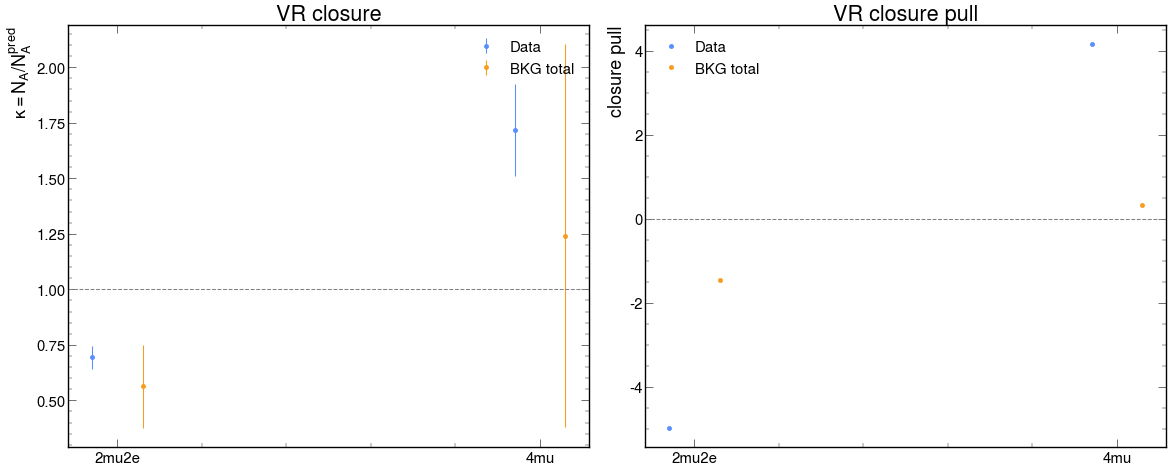

In [12]:
vr_closure = abcd_summary[
    (abcd_summary.selection == "VR") & abcd_summary.group.isin(["Data", "BKG total"])
][["topology", "group", "A", "A_err", "A_pred", "A_pred_err", "kappa", "kappa_err", "pull"]]
display(vr_closure)

if not vr_closure.empty:
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    for i, group in enumerate(["Data", "BKG total"]):
        frame = vr_closure[vr_closure.group == group]
        x = np.arange(len(frame)) + (i-0.5)*0.12
        axes[0].errorbar(x, frame.kappa, yerr=frame.kappa_err, fmt="o", label=group)
        axes[1].plot(x, frame.pull, "o", label=group)
    axes[0].axhline(1, color="gray", ls="--"); axes[1].axhline(0, color="gray", ls="--")
    axes[0].set(ylabel=r"$\kappa=N_A/N_A^{pred}$", title="VR closure")
    axes[1].set(ylabel="closure pull", title="VR closure pull")
    for ax in axes:
        ax.set_xticks(range(len(CHANNEL_CONFIGS)), CHANNEL_CONFIGS.keys()); ax.legend(frameon=False)
    fig.tight_layout()

## 7. SR/VR transferability in MC

`kappa_SR_MC / kappa_VR_MC`가 1에서 벗어나는 정도는 VR closure를 SR로 옮길 때의 추가 systematic 후보이다.

In [13]:
mc_kappa = abcd_summary[abcd_summary.group == "BKG total"].pivot(
    index="topology", columns="selection", values=["kappa", "kappa_err"])
if not mc_kappa.empty:
    transfer_rows = []
    for topology in mc_kappa.index:
        ks, es = mc_kappa.loc[topology, ("kappa", "SR")], mc_kappa.loc[topology, ("kappa_err", "SR")]
        kv, ev = mc_kappa.loc[topology, ("kappa", "VR")], mc_kappa.loc[topology, ("kappa_err", "VR")]
        ratio = ks/kv if kv > 0 else np.nan
        eratio = abs(ratio)*np.sqrt((es/ks)**2+(ev/kv)**2) if ks > 0 and kv > 0 else np.nan
        transfer_rows.append({"topology": topology, "kappa_SR_MC": ks, "kappa_SR_MC_err": es,
                              "kappa_VR_MC": kv, "kappa_VR_MC_err": ev,
                              "R_kappa_SR_over_VR": ratio, "R_kappa_err": eratio})
    transfer_summary = pd.DataFrame(transfer_rows)
else:
    transfer_summary = pd.DataFrame()
display(transfer_summary)

,topology,kappa_SR_MC,kappa_SR_MC_err,kappa_VR_MC,kappa_VR_MC_err,R_kappa_SR_over_VR,R_kappa_err
0,2mu2e,7.336113,8.616655,0.564183,0.186956,13.003062,15.868980
1,4mu,317.920599,493.711043,1.241316,0.862354,256.115695,435.715803


## 8. Blinded SR Data prediction

세 후보를 함께 출력한다.

1. raw SR Data B×C/D
2. VR Data κ correction
3. SR MC κ correction

최종 correction/systematic 선택은 closure 검토 후 결정한다.

In [14]:
prediction_rows = []
for topology in CHANNEL_CONFIGS:
    def one(selection, group):
        f = abcd_summary[(abcd_summary.topology == topology) &
                         (abcd_summary.selection == selection) &
                         (abcd_summary.group == group)]
        return None if f.empty else f.iloc[0]
    sr_data, vr_data, sr_mc = one("SR", "Data"), one("VR", "Data"), one("SR", "BKG total")
    if sr_data is None:
        continue
    raw, eraw = sr_data.A_pred, sr_data.A_pred_err
    def corrected(k, ek):
        val = k*raw
        err = abs(val)*np.sqrt((ek/k)**2+(eraw/raw)**2) if k > 0 and raw > 0 else np.nan
        return val, err
    vr_val, vr_err = corrected(vr_data.kappa, vr_data.kappa_err) if vr_data is not None else (np.nan, np.nan)
    mc_val, mc_err = corrected(sr_mc.kappa, sr_mc.kappa_err) if sr_mc is not None else (np.nan, np.nan)
    prediction_rows.append({"topology": topology,
        "SR_Data_B": sr_data.B, "SR_Data_C": sr_data.C, "SR_Data_D": sr_data.D,
        "raw_prediction": raw, "raw_prediction_err": eraw,
        "VR_Data_kappa_prediction": vr_val, "VR_Data_kappa_prediction_err": vr_err,
        "SR_MC_kappa_prediction": mc_val, "SR_MC_kappa_prediction_err": mc_err})
sr_prediction = pd.DataFrame(prediction_rows)
display(sr_prediction)

,topology,SR_Data_B,SR_Data_C,SR_Data_D,raw_prediction,raw_prediction_err,VR_Data_kappa_prediction,VR_Data_kappa_prediction_err,SR_MC_kappa_prediction,SR_MC_kappa_prediction_err
0,2mu2e,112.0,166.0,272.0,68.352941,9.329397,47.416435,7.409057,501.444897,592.936958
1,4mu,18.0,174.0,13.0,240.923077,89.572128,413.750555,161.800184,76594.409015,122307.692716


## 9. Working-point stability

VR Data, VR MC, SR MC에서 동일한 isolation cut scan을 수행한다. 낮은 control yield와 큰 statistical uncertainty가 있는 point는 선택하지 않는다.

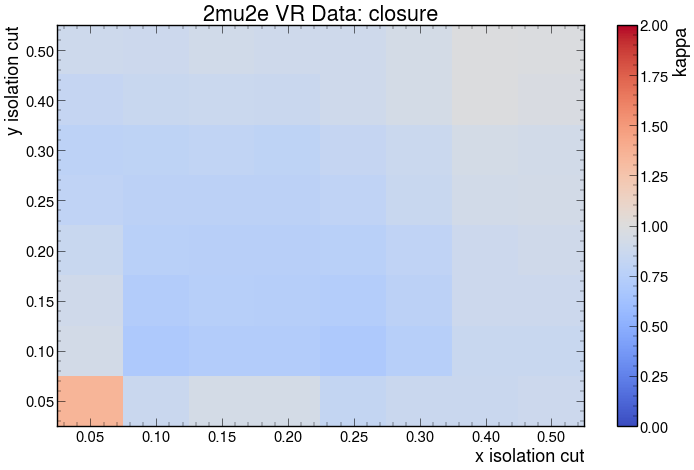

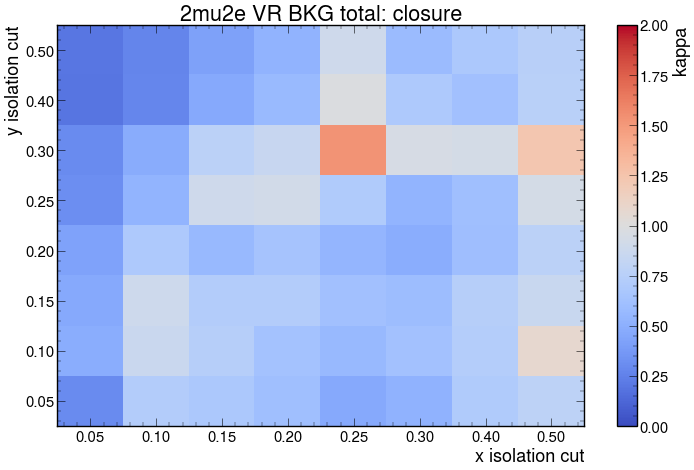

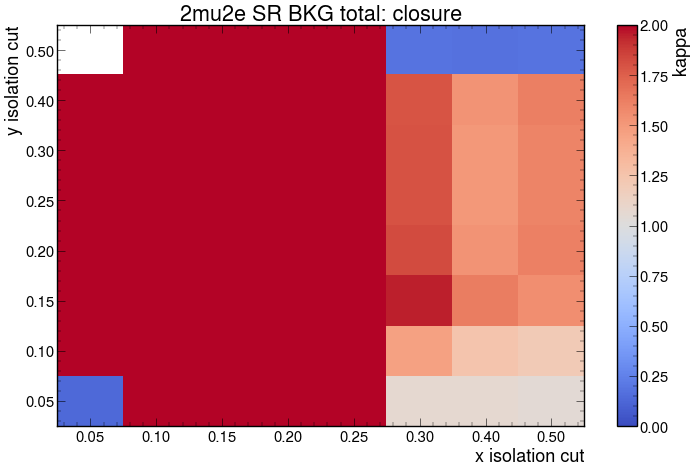

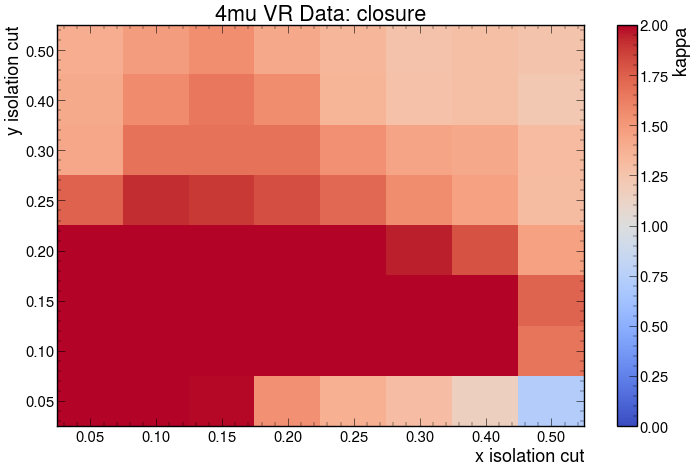

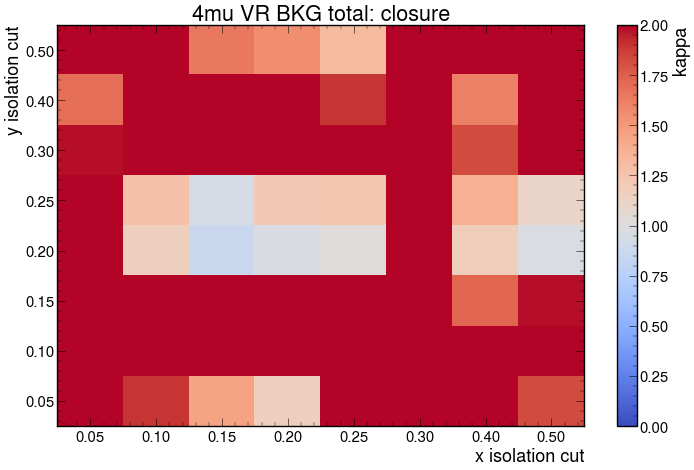

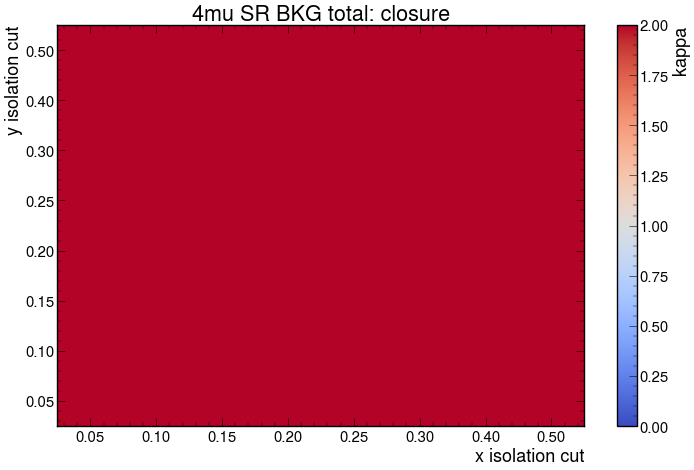

In [17]:
def scan_working_points(h2d, scan_values):
    rows = []
    for xcut in scan_values:
        for ycut in scan_values:
            y, pred, epred, kappa, ekappa, pull = closure(h2d, (xcut, ycut))
            rows.append({"xcut": xcut, "ycut": ycut, "kappa": kappa, "kappa_err": ekappa,
                         "pull": pull, "pred": pred,
                         "relative_pred_err": epred/pred if pred > 0 else np.nan,
                         "min_control_yield": min(y[r][0] for r in ["B", "C", "D"])})
    return pd.DataFrame(rows)


def heatmap(frame, value, title, cmap="viridis", vmin=None, vmax=None):
    table = frame.pivot(index="ycut", columns="xcut", values=value)
    fig, ax = plt.subplots(figsize=(15, 10))
    im = ax.imshow(table.values, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(table.columns)), [f"{x:.2f}" for x in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{y:.2f}" for y in table.index])
    ax.set(xlabel="x isolation cut", ylabel="y isolation cut", title=title)
    fig.colorbar(im, ax=ax, label=value); fig.tight_layout()


wp_scans = {}
for topology in CHANNEL_CONFIGS:
    for selection, group in [("VR", "Data"), ("VR", "BKG total"), ("SR", "BKG total")]:
        h2d = group_hist(group, topology, selection)
        if h2d is None:
            continue
        key = (topology, selection, group)
        wp_scans[key] = scan_working_points(h2d, SCAN_VALUES)
        heatmap(wp_scans[key], "kappa", f"{topology} {selection} {group}: closure", "coolwarm", 0, 2)
        plt.show()

## 10. Correlation and background composition diagnostics

In [18]:
def weighted_corr(h2d):
    w, _ = values_variances(h2d)
    x, y = np.meshgrid(h2d.axes[0].centers, h2d.axes[1].centers, indexing="ij")
    mask = np.isfinite(w) & (w > 0)
    if not mask.any(): return np.nan
    w, x, y = w[mask], x[mask], y[mask]
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cov = np.average((x-mx)*(y-my), weights=w)
    vx, vy = np.average((x-mx)**2, weights=w), np.average((y-my)**2, weights=w)
    return cov/np.sqrt(vx*vy) if vx > 0 and vy > 0 else np.nan


corr_rows = []
for topology in CHANNEL_CONFIGS:
    for selection in ["VR", "SR"]:
        for group in [*BACKGROUND_ORDER, "BKG total", "Data"]:
            h2d = group_hist(group, topology, selection)
            if h2d is not None:
                corr_rows.append({"topology": topology, "selection": selection,
                                  "group": group, "weighted_Pearson": weighted_corr(h2d)})
correlation_summary = pd.DataFrame(corr_rows)
display(correlation_summary)

,topology,selection,group,weighted_Pearson
0,2mu2e,VR,QCD,-0.027415
1,2mu2e,VR,DY,-0.446994
2,2mu2e,VR,TTJets,-0.128790
3,2mu2e,VR,Diboson,-0.149571
4,2mu2e,VR,BKG total,-0.040378
5,2mu2e,VR,Data,-0.007203
6,2mu2e,SR,QCD,-0.051574
7,2mu2e,SR,DY,-1.000000
8,2mu2e,SR,TTJets,0.005393
9,2mu2e,SR,Diboson,NaN


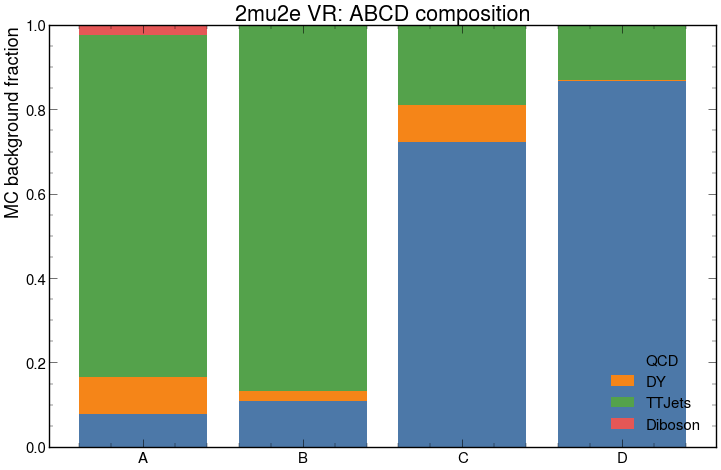

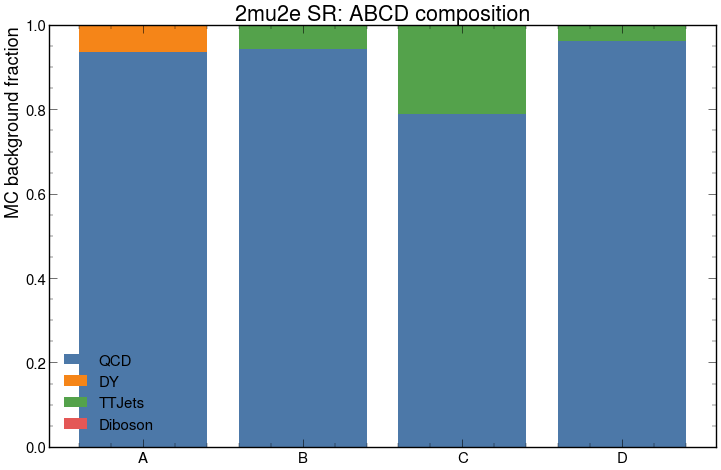

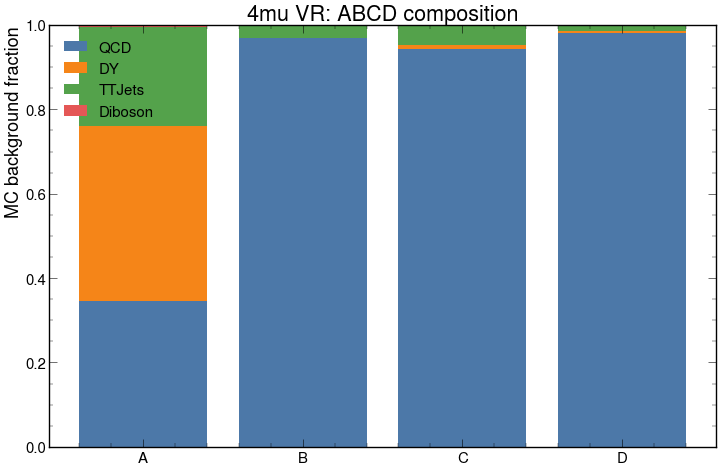

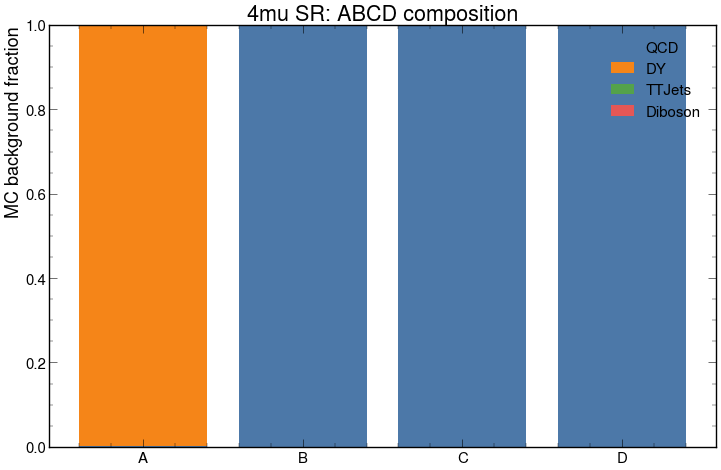

In [20]:
composition = abcd_summary[abcd_summary.group.isin(BACKGROUND_ORDER)].copy()
if not composition.empty:
    for topology in CHANNEL_CONFIGS:
        for selection in ["VR", "SR"]:
            frame = composition[(composition.topology == topology) & (composition.selection == selection)]
            if frame.empty: continue
            regions = ["A", "B", "C", "D"]
            totals = frame[regions].sum(axis=0).to_numpy(float)
            bottom = np.zeros(4)
            fig, ax = plt.subplots(figsize=(15, 10))
            for group in BACKGROUND_ORDER:
                vals = frame.loc[frame.group == group, regions].sum(axis=0).to_numpy(float)
                frac = np.divide(vals, totals, out=np.zeros_like(vals), where=totals != 0)
                ax.bar(regions, frac, bottom=bottom, label=group, color=COLORS[group])
                bottom += frac
            ax.set(ylabel="MC background fraction", ylim=(0,1),
                   title=f"{topology} {selection}: ABCD composition")
            ax.legend(frameon=False); fig.tight_layout(); plt.show()

## 11. Signal efficiency and leakage pilot

여기서 계산되는 `ABCD_*_fraction`은 해당 isolation histogram에 들어온 signal에 대한 조건부 fraction이다. 전체 selection efficiency를 계산하려면 별도의 cutflow 또는 generated-event denominator가 필요하다.

In [21]:
signal_rows = []
for sample in sample_groups.get("Signal", []):
    topology = "2mu2e" if sample.split(":")[0].startswith("2Mu2E_") else "4mu"
    cfg = CHANNEL_CONFIGS[topology]
    region_data = {}
    for selection in ["SR", "VR"]:
        h2d = group_hist(sample, topology, selection)
        if h2d is None: continue
        y = abcd_yields(h2d, cfg["cuts"])
        total = sum(y[r][0] for r in "ABCD")
        region_data[selection] = (y, total)
    sr_total = region_data.get("SR", ({}, 0))[1]
    vr_total = region_data.get("VR", ({}, 0))[1]
    combined = sr_total + vr_total
    row = {"signal": sample, "topology": topology, "SR_2D_yield": sr_total,
           "VR_2D_yield": vr_total, "VR_leakage_fraction": vr_total/combined if combined > 0 else np.nan}
    if "SR" in region_data:
        y, total = region_data["SR"]
        for r in "ABCD": row[f"SR_{r}_fraction"] = y[r][0]/total if total > 0 else np.nan
        row["SR_ABCD_CR_leakage"] = sum(y[r][0] for r in "BCD")/total if total > 0 else np.nan
    signal_rows.append(row)
signal_summary = pd.DataFrame(signal_rows)
display(signal_summary)

,signal,topology,SR_2D_yield,VR_2D_yield,VR_leakage_fraction,SR_A_fraction,SR_B_fraction,SR_C_fraction,SR_D_fraction,SR_ABCD_CR_leakage
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,0.016788,0.000076,0.004515,0.755102,0.009070,0.233560,0.002268,0.244898
1,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,0.160779,0.000167,0.001035,0.782681,0.005594,0.210483,0.001243,0.217319
2,2Mu2E_200GeV_0p25GeV_1p0mm,2mu2e,0.852778,0.000066,0.000078,0.788656,0.013675,0.194095,0.003574,0.211344
3,2Mu2E_200GeV_0p25GeV_5p0mm,2mu2e,0.370305,0.000024,0.000065,0.799413,0.024535,0.170310,0.005742,0.200587
4,2Mu2E_200GeV_0p25GeV_10p0mm,2mu2e,0.195610,0.000000,0.000000,0.790485,0.028362,0.171089,0.010064,0.209515
...,...,...,...,...,...,...,...,...,...,...
115,4Mu_1000GeV_5p0GeV_0p04mm,4mu,0.019965,0.000287,0.014151,0.976077,0.004785,0.019139,0.000000,0.023923
116,4Mu_1000GeV_5p0GeV_0p4mm,4mu,0.533045,0.000731,0.001369,0.987463,0.001371,0.011166,0.000000,0.012537
117,4Mu_1000GeV_5p0GeV_4p0mm,4mu,4.472417,0.000302,0.000068,0.985211,0.001318,0.013387,0.000085,0.014789
118,4Mu_1000GeV_5p0GeV_20p0mm,4mu,1.476987,0.000191,0.000130,0.966131,0.004080,0.029465,0.000324,0.033869


## 12. Final blinded pilot summary

아래 네 표를 저장하면 첫 production test에서 필요한 핵심 진단이 남는다.

- VR Data/MC closure
- SR/VR MC transferability
- blinded SR prediction candidates
- signal leakage

In [22]:
print("VR closure")
display(vr_closure)
print("SR/VR MC transferability")
display(transfer_summary)
print("Blinded SR Data prediction")
display(sr_prediction)
print("Signal leakage")
display(signal_summary)

print("Pilot complete. Keep BLIND_SR_DATA_A=True until formal unblinding approval.")

VR closure


,topology,group,A,A_err,A_pred,A_pred_err,kappa,kappa_err,pull
4,2mu2e,BKG total,113.085248,19.670834,200.440553,56.533991,0.564183,0.186956,-1.459365
5,2mu2e,Data,260.000000,16.124515,374.801790,16.509771,0.693700,0.052769,-4.974613
16,4mu,BKG total,69.983675,19.234431,56.378598,35.971268,1.241316,0.862354,0.333532
17,4mu,Data,129.000000,11.357817,75.115493,6.261286,1.717355,0.208219,4.154762


SR/VR MC transferability


,topology,kappa_SR_MC,kappa_SR_MC_err,kappa_VR_MC,kappa_VR_MC_err,R_kappa_SR_over_VR,R_kappa_err
0,2mu2e,7.336113,8.616655,0.564183,0.186956,13.003062,15.868980
1,4mu,317.920599,493.711043,1.241316,0.862354,256.115695,435.715803


Blinded SR Data prediction


,topology,SR_Data_B,SR_Data_C,SR_Data_D,raw_prediction,raw_prediction_err,VR_Data_kappa_prediction,VR_Data_kappa_prediction_err,SR_MC_kappa_prediction,SR_MC_kappa_prediction_err
0,2mu2e,112.0,166.0,272.0,68.352941,9.329397,47.416435,7.409057,501.444897,592.936958
1,4mu,18.0,174.0,13.0,240.923077,89.572128,413.750555,161.800184,76594.409015,122307.692716


Signal leakage


,signal,topology,SR_2D_yield,VR_2D_yield,VR_leakage_fraction,SR_A_fraction,SR_B_fraction,SR_C_fraction,SR_D_fraction,SR_ABCD_CR_leakage
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,0.016788,0.000076,0.004515,0.755102,0.009070,0.233560,0.002268,0.244898
1,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,0.160779,0.000167,0.001035,0.782681,0.005594,0.210483,0.001243,0.217319
2,2Mu2E_200GeV_0p25GeV_1p0mm,2mu2e,0.852778,0.000066,0.000078,0.788656,0.013675,0.194095,0.003574,0.211344
3,2Mu2E_200GeV_0p25GeV_5p0mm,2mu2e,0.370305,0.000024,0.000065,0.799413,0.024535,0.170310,0.005742,0.200587
4,2Mu2E_200GeV_0p25GeV_10p0mm,2mu2e,0.195610,0.000000,0.000000,0.790485,0.028362,0.171089,0.010064,0.209515
...,...,...,...,...,...,...,...,...,...,...
115,4Mu_1000GeV_5p0GeV_0p04mm,4mu,0.019965,0.000287,0.014151,0.976077,0.004785,0.019139,0.000000,0.023923
116,4Mu_1000GeV_5p0GeV_0p4mm,4mu,0.533045,0.000731,0.001369,0.987463,0.001371,0.011166,0.000000,0.012537
117,4Mu_1000GeV_5p0GeV_4p0mm,4mu,4.472417,0.000302,0.000068,0.985211,0.001318,0.013387,0.000085,0.014789
118,4Mu_1000GeV_5p0GeV_20p0mm,4mu,1.476987,0.000191,0.000130,0.966131,0.004080,0.029465,0.000324,0.033869


Pilot complete. Keep BLIND_SR_DATA_A=True until formal unblinding approval.
